# Simulating a regime-switching diffusion process


<div class="note"><span class="note-t">TL;DR</span>
<p>We control Gaussian position increments with a discrete (pdit) regime cycle to build a regime-switching diffusion sampler in which the only jumps are the latent regime switches. We check the regime-conditioned laws, the stationary occupancy, and the terminal mean against analytic references.</p>
</div>

A **regime-switching (Markov-modulated) diffusion** is a continuous motion whose behavior changes when a hidden discrete state switches. In this tutorial we build one with Torx: the position $X_t$ drifts and diffuses according to a latent regime $S_t$, and only the regime jumps. Because $X_t$ has no discontinuous jump term of its own, this is a latent-jump controlled diffusion rather than a jump-diffusion in $X$.

The regime follows a discrete Markov chain. When it switches, the next position increment comes from a different Gaussian law. We assemble the two parts from `PditCycle` and `MixtureGaussianGate`. The binary-firing `torx.psc.JumpDiffusionGate` is a separate jump model; we do not use it here.

This pattern appears in regime-switching finance, neural spike trains, and other systems where a continuous signal changes its noise level because an unobserved state has changed. Conditioned on the current regime a Gaussian gate gives a Gaussian step, but once the regime is unobserved the same step becomes a non-Gaussian process.

The main steps are:

1. advance a 3-state regime with `PditCycle`, then add a regime-conditioned Gaussian step with `MixtureGaussianGate`,
2. compose the two gates into one Euler step with `HybridPCircuit`, then scan it into joint discrete and continuous sample paths, and
3. check that the one-step law is a mixture of Gaussians, and that the long-run regime occupancy and terminal mean match the analytic references.

The same `MixtureGaussianGate` primitive appears in [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb), and [`12_langevin_graph_ising.ipynb`](12_langevin_graph_ising.ipynb) builds a custom nonlinear Langevin gate on the same continuous `pmode` site.



## Setup

The setup cells wire the imports and plot styling; `mixture_density`, the analytic density reference used below, comes from `examples/helpers/_affine_gaussian.py`.

In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np
from scipy import stats



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)
import _plots_fields as P_fld
import _plots_schematics as P_sch



In [4]:
from _affine_gaussian import mixture_density
from torx.psc import (
    HybridPCircuit,
    HybridSampleSimulator,
    MixtureGaussianGate,
    PditCycle,
)



In [5]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)
SEED = 123

## The process and its gates

The target is a regime-switching stochastic differential equation (SDE): a position $X_t$ whose drift and volatility are both set by a latent regime $S_t$. That regime is a continuous-time Markov chain, and `PditCycle` realizes its $O(\Delta t)$ Euler discretization with switch probabilities linear in $\Delta t$.

$$
dX_t = \underbrace{\mu_{S_t}\,dt}_{\vphantom{\big|}\text{drift}} + \underbrace{\sigma_{S_t}\,dW_t}_{\vphantom{\big|}\text{diffusion}}.
$$

Here $W_t$ is a standard Wiener (Brownian) process, and the current regime selects $(\mu, \sigma)$ for the continuous increment.

This discrete control changes the transition kernel: the increment is Gaussian once we condition on a regime, and marginalizing over an unobserved regime turns it into a mixture of Gaussians.

The generator, the operator describing how the distribution changes over an instant, splits into a regime part and a position part, $A = A_S + A_X$. The two pieces do not commute, so the order of the approximation matters.

One Trotter step applies them in sequence: switch the regime first, then take the position step under the new regime. This is the Lie-Trotter split: its local one-step error is $O(\Delta t^2)$, giving first-order $O(\Delta t)$ global error over the full interval.

$$
T_{\text{Trotter}}(\Delta t) = \underbrace{T_{\text{MoG}}(\Delta t)}_{\vphantom{\big|}\text{position step}}\, \underbrace{T_{\text{PditCycle}}(\Delta t)}_{\vphantom{\big|}\text{regime switch}}.
$$

The `PditCycle` gate advances the regime on a cyclic 3-state chain. At each step of size $\Delta t$ it:

- moves forward with probability $p_+ = \lambda_+\Delta t$,
- moves backward with probability $p_- = \lambda_-\Delta t$, and
- stays put with probability $p_0 = 1 - p_+ - p_-$.

The `MixtureGaussianGate` gate then applies the regime-conditioned increment:

$$
X' = X + \mu_k\,\Delta t + \sigma_k\sqrt{\Delta t}\,\mathcal{N}(0,1)\quad\text{when } S = k .
$$

We use $K=3$ regimes with $\mu = (1.0,\,0.0,\,-0.8)$, $\sigma = (0.3,\,1.0,\,0.5)$, and rates $\lambda_+ = 0.5$ and $\lambda_- = 0.3$.


In [6]:
K = 3
mu = jnp.array([1.0, 0.0, -0.8])
sigma = jnp.array([0.3, 1.0, 0.5])
lambda_plus = 0.5
lambda_minus = 0.3



In [7]:
T = 10.0
num_steps = 120
num_trajectories = 20_000

dt = T / num_steps



In [8]:
# Convert continuous-time rates into one-step transition probabilities.
p_forward = lambda_plus * dt
p_backward = lambda_minus * dt
p_stay = 1.0 - p_forward - p_backward


Both gates use log-space parameters. `PditCycle` takes the log odds of moving forward or backward relative to staying, and `MixtureGaussianGate` takes per-regime means and log variances.

In [9]:
# PditCycle expects log odds against the stay event.
cycle_theta = jnp.log(jnp.array([p_forward / p_stay, p_backward / p_stay]))

# Each regime has its own one-dimensional Gaussian increment.
mog_theta = {
    "means": (mu * dt)[:, None],
    "log_vars": jnp.log((sigma**2 * dt)[:, None]),
}

In [10]:
print(
    f"dt={dt:.4f}  |  "
    f"λ+={lambda_plus}, λ-={lambda_minus}  |  "
    f"μ={mu.tolist()}  |  "
    f"σ={sigma.tolist()}  |  "
    f"trajectories={num_trajectories}"
)
print(f"p_forward={p_forward:.4f}  p_backward={p_backward:.4f}  p_stay={p_stay:.4f}")

dt=0.0833  |  λ+=0.5, λ-=0.3  |  μ=[1.0, 0.0, -0.800000011920929]  |  σ=[0.30000001192092896, 1.0, 0.5]  |  trajectories=20000
p_forward=0.0417  p_backward=0.0250  p_stay=0.9333


## The regime chain

Solid edges show the forward cycle at rate $\lambda_+$, tinted by their source regime. Dashed edges show the backward cycle at rate $\lambda_-$ in a single neutral color. The self-loops for the stay probability $p_0$ are omitted so the drawing focuses on transitions between regimes.

Because the chain is rotationally symmetric, its stationary distribution, the long-run fraction of time spent in each regime, is uniform $(1/3, 1/3, 1/3)$ for any split between the forward and backward rates. The occupancy check at the end confirms this empirically.

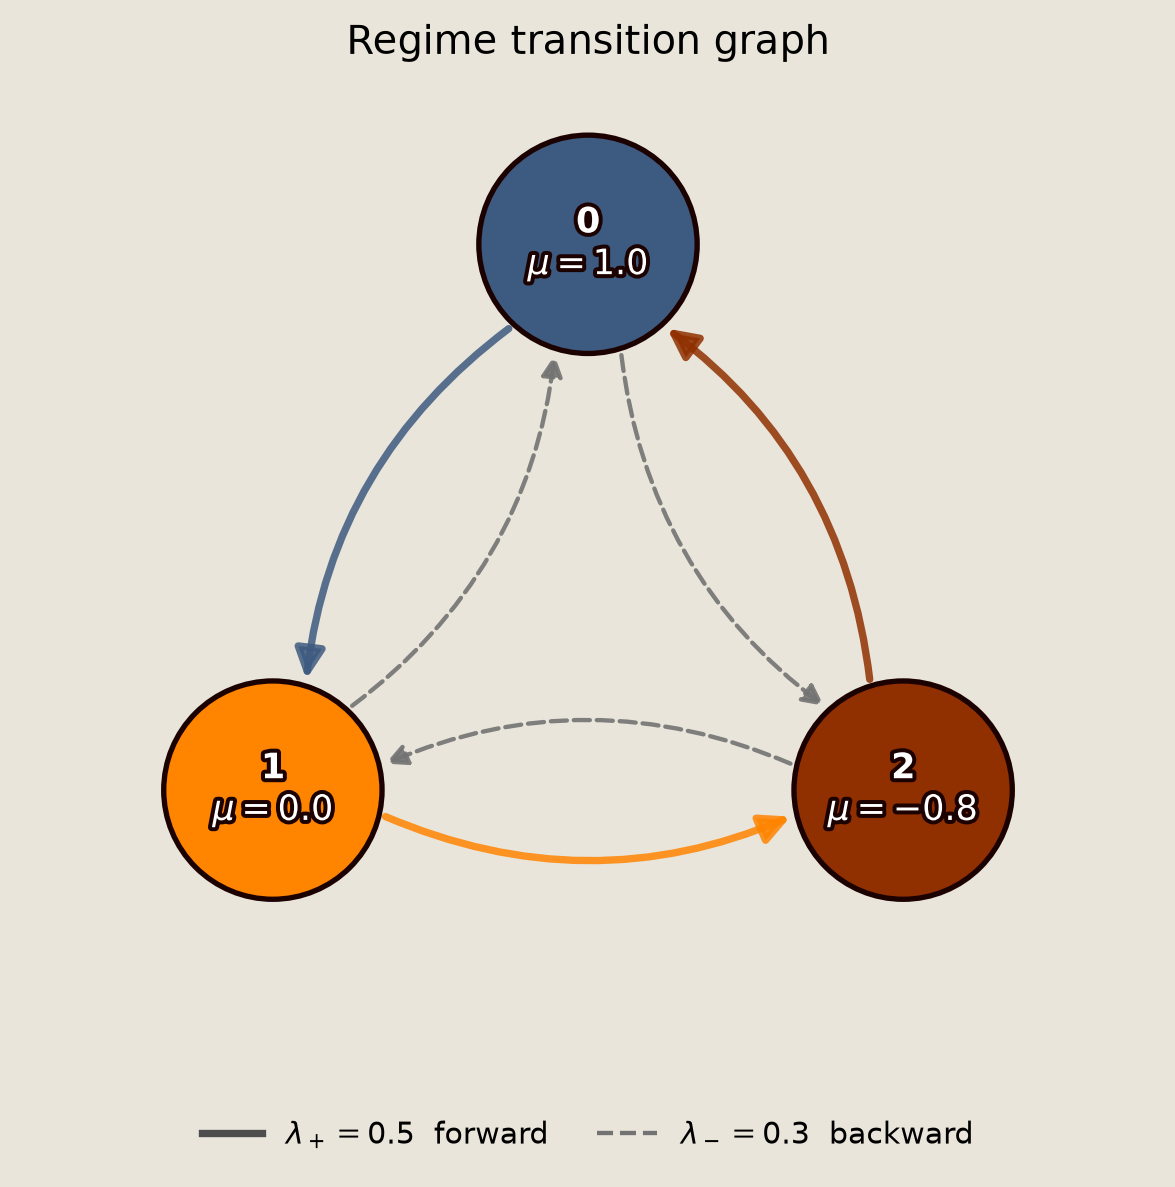

In [11]:
fig_g = P_sch.draw_regime_chain(
    mu=mu,
    lambda_plus=lambda_plus,
    lambda_minus=lambda_minus,
)
savefig(fig_g, "13_regime_transition_graph")

Every switch is a single forward or backward step around the ring. For $K=3$ both non-self states are nearest neighbors, so one step can reach either. On larger rings this would permit only nearest-neighbor moves.

## Building the one-step circuit

We use the Trotter split $T_{\text{Trotter}} = T_{\text{MoG}}\,T_{\text{PditCycle}}$ to update the regime wire $|S)$ first. The Gaussian gate then samples the position increment on the wire $|X)$, conditioned on the new regime.

In [12]:
one_step = HybridPCircuit(
    [
        PditCycle(sites=0, dims=K),
        MixtureGaussianGate(sites=(0, 0), dims=(1,), num_components=K),
    ]
)

# Parameters are kept separate from the circuit, one pytree per gate in gate order.
thetas = [cycle_theta, mog_theta]

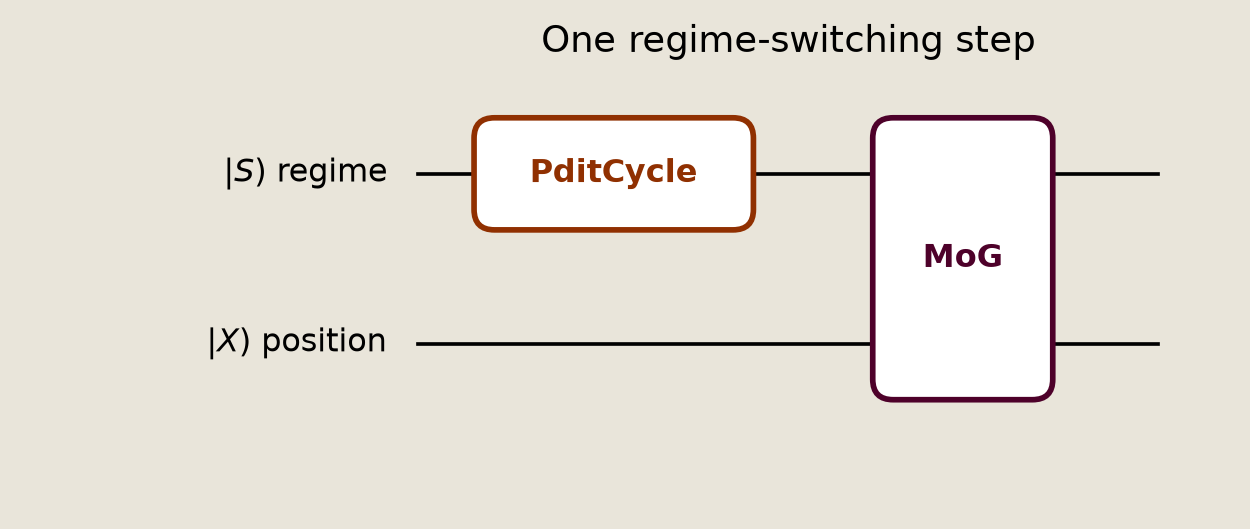

In [13]:
fig_c = P_sch.draw_pcircuit(
    # MoG spans both wires: it reads the regime wire 0 and writes the position wire 1
    [("PditCycle", [0]), ("MoG", [0, 1])],
    wire_labels=[r"$|S)$ regime", r"$|X)$ position"],
    title="One regime-switching step",
)
savefig(fig_c, "13_one_step_circuit")

The regime wire $|S)$ is updated before it conditions the Gaussian increment on $|X)$, so each step samples the position under the freshly switched regime.

## Scanning the trajectories

The `HybridSampleSimulator` class runs one path at a time with `num_samples` set to `1`.

In [14]:
sim = HybridSampleSimulator(num_samples=1)
compiled = sim.build_circuit(one_step, thetas)

The `scan` function carries the discrete and continuous state through each compiled step. The `vmap` transform then batches the 20,000 trajectory keys into one compiled computation.

In [15]:
@eqx.filter_jit
def simulate_trajectories(keys):
    def simulate_one(key):
        # Split once so every timestep gets an independent random key.
        step_keys = jax.random.split(key, num_steps)
        init = {
            "discrete": jnp.array([0], dtype=jnp.int32),
            "continuous": jnp.zeros(1),
        }

        def step(state, step_key):
            result = sim.sample(compiled, state, step_key)
            sampled_discrete = result["discrete"][0]
            sampled_continuous = result["continuous"][0]
            new_state = {
                "discrete": sampled_discrete,
                "continuous": sampled_continuous,
            }
            # why: num_samples=1 leaves a leading axis; carry drops it and scan stores scalars.
            return new_state, (sampled_discrete[0], sampled_continuous[0])

        _, path = jax.lax.scan(step, init, step_keys)
        return path

    return jax.vmap(simulate_one)(keys)


In [16]:
keys = jax.random.split(jax.random.key(SEED), num_trajectories)
regimes, positions = simulate_trajectories(keys)

regimes = np.asarray(regimes)
positions = np.asarray(positions)

# prepend the initial state (t=0, regime 0, position 0) so occupancy and path
# plots start at t=0, before the first PditCycle transition
init_regime = np.zeros((num_trajectories, 1), dtype=regimes.dtype)
init_position = np.zeros((num_trajectories, 1), dtype=positions.dtype)
regimes = np.concatenate([init_regime, regimes], axis=1)
positions = np.concatenate([init_position, positions], axis=1)
time = np.linspace(0.0, T, num_steps + 1)

assert regimes.shape == (num_trajectories, num_steps + 1), regimes.shape
assert positions.shape == (num_trajectories, num_steps + 1), positions.shape
assert set(np.unique(regimes)).issubset(set(range(K))), "invalid regime index"
assert np.all(np.isfinite(positions)), "non-finite positions"

print(
    f"regimes shape: {regimes.shape}   positions shape: {positions.shape}\n"
    f"regime values present: {sorted(np.unique(regimes).tolist())}\n"
    f"position range: [{positions.min():.2f}, {positions.max():.2f}]"
)

regimes shape: (20000, 121)   positions shape: (20000, 121)
regime values present: [0, 1, 2]
position range: [-12.21, 14.83]


## The one-step transition density

One application of `PditCycle` followed by `MixtureGaussianGate` produces a Gaussian mixture.

Conditioning on the new regime $k$ gives the Gaussian increment $\mathcal{N}(\mu_k\Delta t,\,\sigma_k^2\Delta t)$. Marginalizing over regimes (averaging across all possible regimes) with the stationary weights $\pi = (1/3, 1/3, 1/3)$ gives $\Delta x \sim \sum_k \pi_k\,\mathcal{N}(\mu_k\Delta t,\,\sigma_k^2\Delta t)$.

The pooled sample below starts equally often from each regime. Because this `PditCycle` chain is doubly stochastic (rows and columns each sum to 1), that uniform start remains uniform after one step, so pooling per-regime samples reproduces the stationary marginal.

The discrete control is what makes the kernel non-Gaussian; compositions of pure-Gaussian gates stay Gaussian.

As a check, we sample the one-step increments $\Delta x$ from each starting regime and compare them with the analytic densities.


In [17]:
N_PER_REGIME = 20_000
sim_one = HybridSampleSimulator(num_samples=N_PER_REGIME)
compiled_one = sim_one.build_circuit(one_step, thetas)

In [18]:
def sample_one_step_by_regime(sim_one, compiled_one, K, seed):
    """Sample one circuit step started from each regime; return new regimes and increments."""
    new_regimes_list, increments_list = [], []
    base_key = jax.random.key(seed)
    for start_regime in range(K):
        # Start equally from each regime; samples are grouped by the new regime
        # S_{n+1} below, so the conditional laws are conditioned on S_{n+1}.
        init_state = {
            "discrete": jnp.array([start_regime], dtype=jnp.int32),
            "continuous": jnp.zeros(1),
        }
        samples_k = sim_one.sample(
            compiled_one,
            init_state,
            jax.random.fold_in(base_key, start_regime),
        )
        new_regimes_list.append(np.asarray(samples_k["discrete"])[:, 0])
        increments_list.append(np.asarray(samples_k["continuous"])[:, 0])

    all_new_regimes = np.concatenate(new_regimes_list)
    all_increments = np.concatenate(increments_list)
    return all_new_regimes, all_increments


In [19]:
all_new_regimes, all_increments = sample_one_step_by_regime(
    sim_one,
    compiled_one,
    K,
    SEED,
)

print(
    f"{K * N_PER_REGIME} total samples; new-regime counts: "
    f"{[int((all_new_regimes == k).sum()) for k in range(K)]}"
)

60000 total samples; new-regime counts: [20010, 19984, 20006]


In [20]:
conditional_increments = [all_increments[all_new_regimes == k] for k in range(K)]
marginal_increments = all_increments
pi_stat = np.full(K, 1.0 / K)

regime_means = np.asarray(mu * dt)
regime_vars = np.asarray(sigma**2 * dt)

print("regime  mean(Δx)   var(Δx)")
for k in range(K):
    print(f"  {k}     {regime_means[k]:+.4f}    {regime_vars[k]:.4f}")

regime  mean(Δx)   var(Δx)
  0     +0.0833    0.0075
  1     +0.0000    0.0833
  2     -0.0667    0.0208


We evaluate the analytic conditional and mixture densities on a shared grid with the `mixture_density` helper, then overlay them on the sampled histograms.

In [21]:
# A shared grid makes the conditional and marginal curves directly comparable.
x_lo = regime_means.min() - 4.0 * np.sqrt(regime_vars.max())
x_hi = regime_means.max() + 4.0 * np.sqrt(regime_vars.max())
x_grid = np.linspace(x_lo, x_hi, 400)



In [22]:
conditional_pdfs = [
    np.asarray(
        mixture_density(
            mog_theta["means"][k : k + 1],
            mog_theta["log_vars"][k : k + 1],
            jnp.array([1.0]),
            jnp.asarray(x_grid),
        )
    )
    for k in range(K)
]
marginal_pdf = np.asarray(
    mixture_density(
        mog_theta["means"],
        mog_theta["log_vars"],
        jnp.asarray(pi_stat),
        jnp.asarray(x_grid),
    )
)



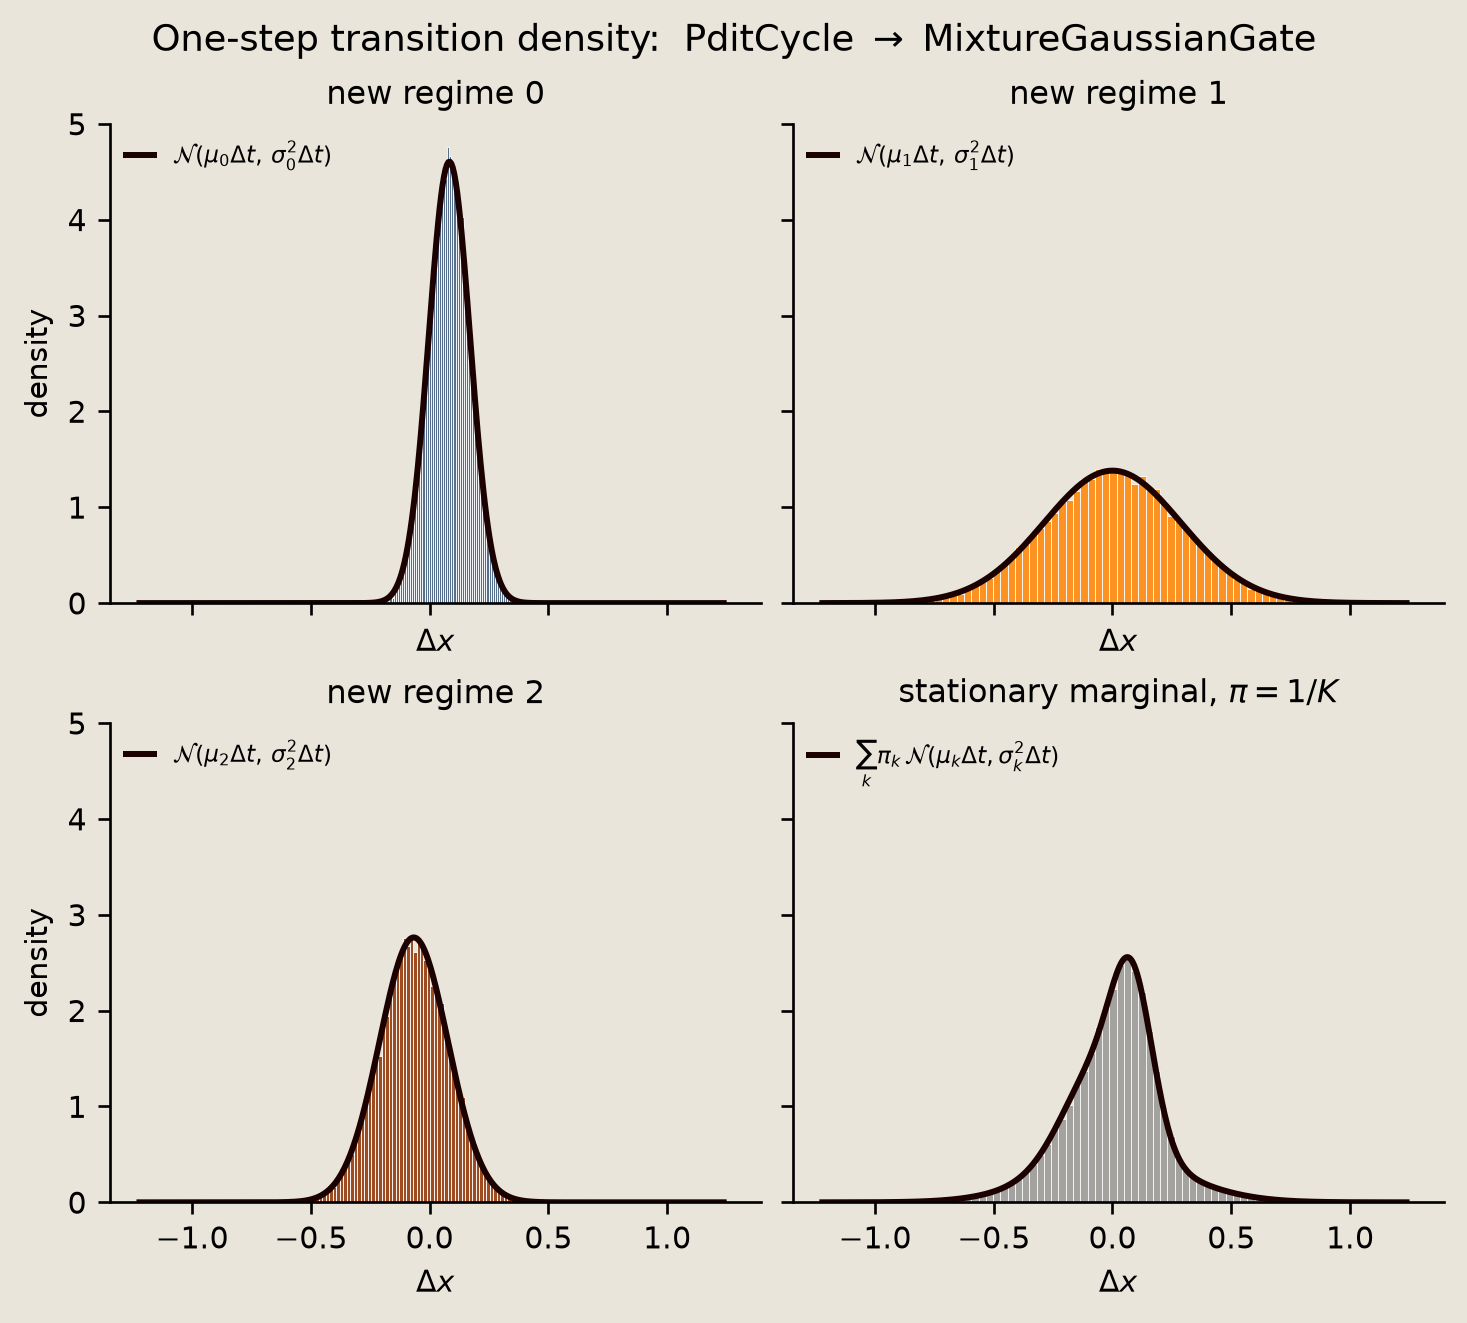

In [23]:
fig = P_fld.plot_transition_density(
    conditional_increments,
    marginal_increments,
    x_grid,
    conditional_pdfs,
    marginal_pdf,
)
savefig(fig, "13_mog_transition_density")

Regimes 0 and 2 give narrow conditional Gaussians, while regime 1 gives a wide one. The stationary marginal blends all three, so it is wider than the sharpest conditional and skewed toward the regime-0 drift.


### Sample-law checks

The exact target law lets us check the full distribution.

Each regime-conditional increment is $\mathcal{N}(\mu_k\Delta t,\sigma_k^2\Delta t)$, and the stationary marginal is the mixture $\sum_k \pi_k\,\mathcal{N}(\mu_k\Delta t,\sigma_k^2\Delta t)$.

The Kolmogorov-Smirnov (KS) statistic measures the largest gap between the empirical and true cumulative distribution function (CDF), where 0 is perfect.

The checks below report KS D per regime and for the stationary marginal, then verify the sample means and variances against the analytic moments.


In [24]:
def ks_statistic(samples, cdf):
    # KS D straight from the empirical vs theoretical CDF, bypassing scipy's KS
    # wrapper (its _axis_nan_policy path regressed on scipy 1.18); norm.cdf is fine.
    xs = np.sort(np.asarray(samples, dtype=float))
    n = len(xs)
    cdf_vals = np.asarray(cdf(xs), dtype=float)
    d_plus = np.max(np.arange(1, n + 1) / n - cdf_vals)
    d_minus = np.max(cdf_vals - np.arange(0, n) / n)
    return float(max(d_plus, d_minus))




In [25]:
def mixture_cdf(x):
    """Stationary-mixture CDF of the one-step increment."""
    return sum(
        pi_stat[k] * stats.norm.cdf(x, regime_means[k], np.sqrt(regime_vars[k]))
        for k in range(K)
    )




In [26]:
print("target                         KS D")
ks_stats = []
for k in range(K):
    inc = conditional_increments[k]
    loc, scale = regime_means[k], float(np.sqrt(regime_vars[k]))
    D = ks_statistic(inc, lambda x, loc=loc, scale=scale: stats.norm.cdf(x, loc, scale))
    ks_stats.append(D)
    print(f"  Δx | new regime = {k}         {D:.4f}")

D_mix = ks_statistic(marginal_increments, mixture_cdf)
ks_stats.append(D_mix)
print(f"  Δx  (stationary mixture)       {D_mix:.4f}")

min_ks_samples = min([len(inc) for inc in conditional_increments] + [len(marginal_increments)])
ks_tol = 5.0 / np.sqrt(min_ks_samples)
# why: KS sampling error falls as 1/sqrt(n).
if max(ks_stats) >= ks_tol:
    raise AssertionError(
        f"KS D too large: {max(ks_stats):.4f} >= {ks_tol:.4f} "
        "(increments not matching the law)"
    )
print(
    f"\nall KS D < {ks_tol:.4f}; one-step increments match the analytic transition law"
)


target                         KS D
  Δx | new regime = 0         0.0060
  Δx | new regime = 1         0.0051
  Δx | new regime = 2         0.0101
  Δx  (stationary mixture)       0.0036

all KS D < 0.0354; one-step increments match the analytic transition law


In [27]:
for k in range(K):
    inc_k = conditional_increments[k]
    if len(inc_k) <= 100:
        raise AssertionError(f"too few samples for regime {k}")
    mean_atol = 7.0 * np.sqrt(regime_vars[k] / len(inc_k))
    var_rtol = 10.0 * np.sqrt(2.0 / (len(inc_k) - 1))
    np.testing.assert_allclose(inc_k.mean(), regime_means[k], atol=mean_atol)
    np.testing.assert_allclose(inc_k.var(), regime_vars[k], rtol=var_rtol)



In [28]:
mix_mean_exact = float((pi_stat * regime_means).sum())
mix_var_exact = float(
    (pi_stat * (regime_vars + regime_means**2)).sum() - mix_mean_exact**2
)
marginal_mean_atol = 7.0 * np.sqrt(mix_var_exact / len(marginal_increments))
marginal_var_rtol = 10.0 * np.sqrt(2.0 / (len(marginal_increments) - 1))
np.testing.assert_allclose(
    marginal_increments.mean(), mix_mean_exact, atol=marginal_mean_atol
)
np.testing.assert_allclose(marginal_increments.var(), mix_var_exact, rtol=marginal_var_rtol)



In [29]:
print("per-regime Torx moments match analytic to MC tolerance.")
print(
    f"stationary marginal:  Torx mean = {marginal_increments.mean():+.4f}, "
    f"analytic = {mix_mean_exact:+.4f}"
)
print(
    f"stationary marginal:  Torx var  = {marginal_increments.var():.4f}, "
    f"analytic = {mix_var_exact:.4f}"
)


per-regime Torx moments match analytic to MC tolerance.
stationary marginal:  Torx mean = +0.0066, analytic = +0.0056
stationary marginal:  Torx var  = 0.0410, analytic = 0.0410


## Sample paths

The sampled trajectories show how regime changes alter the continuous motion.

The figure shows 18 paths, with each segment colored by its active regime. A color change along a path marks a regime jump. Blue is regime 0 with upward drift $\mu=1.0$, orange is regime 1 with pure diffusion $\mu=0.0$, and dark red is regime 2 with downward drift $\mu=-0.8$.

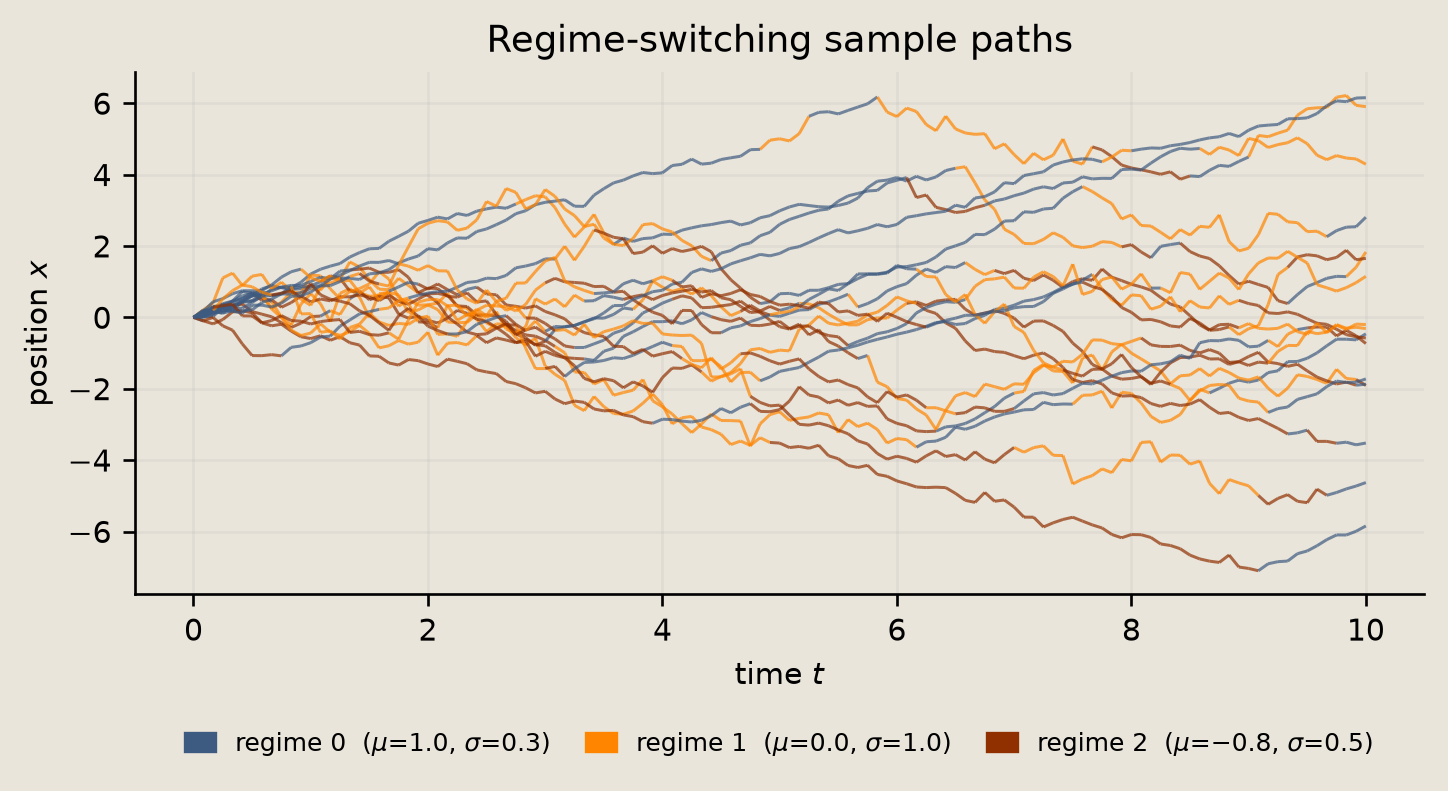

In [30]:
fig = P_fld.plot_sample_paths(time, positions, regimes, mu=mu, sigma=sigma, n_show=18)
savefig(fig, "13_regime_switching_diffusion_trajectories")

In the color bands, blue segments drift up, dark red segments drift down, and orange segments wander widest. The active regime sets both the direction and the spread of every increment.

## Regime occupancy

Regime occupancy summarizes how the discrete chain mixes.

At each timestep, `occupancy` is the fraction of paths in each regime. The three stacked bands sum to `1` at every $t$. All paths start in regime 0, so the bands begin with all mass in that regime and then relax toward the uniform stationary distribution $(1/3, 1/3, 1/3)$.

In [31]:
occupancy = np.stack([(regimes == k).mean(axis=0) for k in range(K)])

np.testing.assert_allclose(occupancy.sum(axis=0), 1.0, atol=1e-6)
print("regime occupancy sums to 1 at every step")
print(f"time-mean occupancies: {occupancy.mean(axis=1).round(3).tolist()}")

regime occupancy sums to 1 at every step
time-mean occupancies: [0.388, 0.313, 0.299]


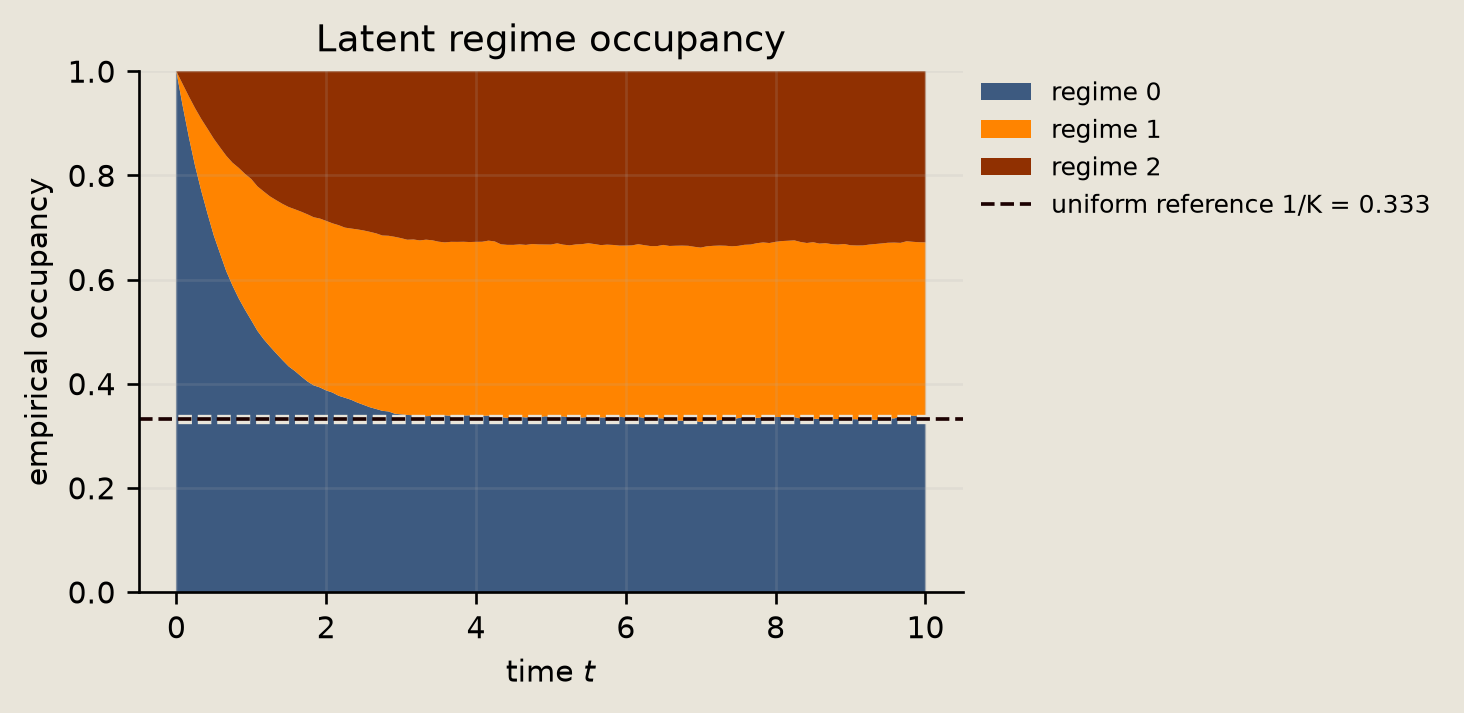

In [32]:
fig = P_fld.plot_regime_occupancy(time, occupancy)
savefig(fig, "13_regime_switching_diffusion_regime_histogram")

The regime-0 band falls from 1 and the other two rise. Once the chain forgets its start, all three settle near $1/3$.

## Verification

Two quantitative checks close the notebook.

First, the back-half time-mean occupancy across the sampled paths should reach the uniform stationary distribution $(1/3, 1/3, 1/3)$ once the chain has mixed.

Second, the empirical terminal $E[x_T]$ should match the analytic per-step mean propagation.


First we check that the back-half occupancy has reached the uniform stationary distribution.

In [33]:
uniform_stationary = np.full(K, 1.0 / K)
back_half_occupancy = occupancy[:, num_steps // 2 :].mean(axis=1)
max_dev_back = float(np.max(np.abs(back_half_occupancy - uniform_stationary)))

# why: paths are independent, while back-half time points are correlated.
occupancy_tol = 1.35 / np.sqrt(num_trajectories)

print(
    f"back-half occupancy (mean for t > T/2): {back_half_occupancy.round(4).tolist()}"
)
print(f"uniform stationary  (1/K, 1/K, 1/K):    {uniform_stationary.round(4).tolist()}")
print(f"max |empirical - stationary|:           {max_dev_back:.4f}  (tol {occupancy_tol:.4f})")
if max_dev_back >= occupancy_tol:
    raise AssertionError(
        f"back-half occupancy deviates from uniform stationary by {max_dev_back:.4f} "
        f">= {occupancy_tol:.4f}; chain may not be mixed or sample count too small"
    )


back-half occupancy (mean for t > T/2): [0.3339, 0.3341, 0.332]
uniform stationary  (1/K, 1/K, 1/K):    [0.3333, 0.3333, 0.3333]
max |empirical - stationary|:           0.0014  (tol 0.0095)


Then we propagate the regime distribution through the transition matrix to get the analytic terminal mean and compare it with the empirical one.

In [34]:
T_matrix = np.asarray(PditCycle(sites=0, dims=K).get_matrix(cycle_theta))
regime_dist = np.array([1.0, 0.0, 0.0])
analytic_terminal_mean = 0.0
for _ in range(num_steps):
    # why: Torx uses column-stochastic p_next = T @ p, matching the sampler.
    regime_dist = T_matrix @ regime_dist
    analytic_terminal_mean += float((regime_dist * np.asarray(mu)).sum()) * dt

empirical_terminal_mean = float(positions[:, -1].mean())
empirical_terminal_sem = float(positions[:, -1].std(ddof=1) / np.sqrt(num_trajectories))

print()
print(
    f"terminal E[x_T]:  analytic = {analytic_terminal_mean:+.4f}, "
    f"empirical = {empirical_terminal_mean:+.4f}  "
    f"(SE {empirical_terminal_sem:.3f} from {num_trajectories} paths)"
)

# why: terminal mean error is Monte Carlo standard error over independent paths.
terminal_tol = 4.0 * empirical_terminal_sem
if abs(empirical_terminal_mean - analytic_terminal_mean) >= terminal_tol:
    raise AssertionError(
        f"terminal mean off by {empirical_terminal_mean - analytic_terminal_mean:+.4f} "
        f"(tolerance ±{terminal_tol:.3f})"
    )



terminal E[x_T]:  analytic = +1.4052, empirical = +1.4295  (SE 0.024 from 20000 paths)


The empirical terminal mean lands within four standard errors of the analytic propagation; the summary below collects the run statistics.

In [35]:
print()
print(f"Regime-switching diffusion  (K=3 regimes, 120 steps, {num_trajectories} paths)")
print(f"  position range          : [{positions.min():+.3f}, {positions.max():+.3f}]")
print(f"  terminal mean (empir.)  : {empirical_terminal_mean:+.4f}")
print(f"  terminal mean (analytic): {analytic_terminal_mean:+.4f}")
print(f"  time-mean occupancy     : {occupancy.mean(axis=1).round(4).tolist()}")
print(f"  back-half occupancy     : {back_half_occupancy.round(4).tolist()}")
print(f"  occupancy vs stationary : max dev {max_dev_back:.4f}")


Regime-switching diffusion  (K=3 regimes, 120 steps, 20000 paths)
  position range          : [-12.215, +14.826]
  terminal mean (empir.)  : +1.4295
  terminal mean (analytic): +1.4052
  time-mean occupancy     : [0.3881, 0.3132, 0.2987]
  back-half occupancy     : [0.3339, 0.3341, 0.332]
  occupancy vs stationary : max dev 0.0014


## Conclusion

We built a regime-switching diffusion where a pdit-controlled Gaussian mixture gate turns a Gaussian step into a non-Gaussian marginal.

`PditCycle` advances the 3-state regime chain with first-order transition probabilities, and `MixtureGaussianGate` draws the regime-conditioned position increment. `HybridPCircuit` composes the gates into one Euler step, and a jit-compiled `scan` and `vmap` around `HybridSampleSimulator` run 20,000 paths over 120 steps.

The one-step transition density is a mixture of Gaussians that matches the analytic conditionals and the stationary marginal under the uniform, doubly stochastic regime law. The final checks show that the back-half regime occupancy reaches the uniform stationary distribution, and that the empirical terminal $E[x_T]$ matches the analytic mean propagation.

See also:
- [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb), pure affine-Gaussian gates and exact moment propagation.
- [`12_langevin_graph_ising.ipynb`](12_langevin_graph_ising.ipynb), a custom nonlinear Langevin gate sampling a soft-spin energy.
